# Steam 게임 데이터 추가 분석
---

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import koreanize_matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 기본 스타일
sns.set_theme(style='darkgrid', palette='muted')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [39]:
# ── 데이터 로드 & 전처리 ──────────────────────────────────────────
df = pd.read_csv('games.csv')

df.rename(columns={
    'AppID'          : 'Name',
    'Name'           : 'Release date',
    'Release date'   : 'Estimated owners',
    'Estimated owners': 'Peak CCU',
    'Peak CCU'       : 'Required age',
    'Required age'   : 'Price',
    'Price'          : 'Discount',
    'DiscountDLC count': 'DLC Count',
}, inplace=True)

df = df.reset_index().rename(columns={'index': 'AppID'})
df.drop(columns=['Movies'], inplace=True)

# 날짜 파싱
df['Release date'] = pd.to_datetime(df['Release date'], format='%b %d, %Y', errors='coerce')
df['Release year'] = df['Release date'].dt.year

# 긍정 비율
total_reviews = df['Positive'] + df['Negative']
df['Approval rate'] = np.where(total_reviews > 0, df['Positive'] / total_reviews, np.nan)

# Estimated owners 중간값 파싱
owners_split = df['Estimated owners'].str.split(' - ', expand=True)
df['Owners min'] = pd.to_numeric(owners_split[0], errors='coerce')
df['Owners max'] = pd.to_numeric(owners_split[1], errors='coerce')
df['Owners mid'] = (df['Owners min'] + df['Owners max']) / 2

print('로드 완료:', df.shape)
df.head(3)

로드 완료: (122611, 44)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC Count,About the game,...,Publishers,Categories,Genres,Tags,Screenshots,Release year,Approval rate,Owners min,Owners max,Owners mid
0,2539430,Black Dragon Mage Playtest,2023-08-01,0 - 0,0,0,0.00,0,0,NaN,...,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,2023,NaN,0,0,0.0
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,2016,0.988235,0,20000,10000.0
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,2019,0.875000,0,20000,10000.0


In [40]:
df[df['Release date'] == '2025-12-31']

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC Count,About the game,...,Publishers,Categories,Genres,Tags,Screenshots,Release year,Approval rate,Owners min,Owners max,Owners mid
122192,3220430,Mind Hole,2025-12-31,0 - 0,0,0,9.89,0,0,Experimental nightmare insanity simulator. Poi...,...,Trash Vomit Studios,"Single-player,Steam Achievements,Steam Cloud,F...","Adventure,Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122238,3985770,Arrow Spire: Tower Defense,2025-12-31,0 - 0,0,0,2.54,0,0,Defend. Upgrade. Rise higher. Arrow Spire: Tow...,...,Kettle Studio,"Single-player,Steam Achievements,Stats,Family ...","Casual,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122256,2903580,Dissociative,2025-12-31,0 - 0,0,0,17.99,0,0,Play through a merging and dissociating betwee...,...,Trash Vomit Studios,"Single-player,Steam Achievements,Partial Contr...","Adventure,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122261,3486280,Long Knives,2025-12-31,0 - 0,0,0,0.00,0,0,English localization only available in Demo. D...,...,Jade Hex,Single-player,"Adventure,Indie,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122291,4127210,Late for School,2025-12-31,0 - 0,0,0,4.99,0,0,"Late for School is a cozy, kid-friendly drivin...",...,Essential Skills Software Inc,"Single-player,Family Sharing","Action,Casual,Indie,Racing,Simulation,Early Ac...",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122303,3242500,Quantum Curse,2025-12-31,0 - 0,0,0,13.49,0,0,Awaken as a prototype failsafe experiment unbe...,...,Trash Vomit Studios,"Single-player,Steam Achievements,Partial Contr...","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122306,4155460,我獨自升級英文(1),2025-12-31,0 - 0,0,0,12.79,0,0,===一套遊戲二套玩法=== (1)劇情冒限模式(適合一邊玩一邊學習) 以傳統RPG遊戲的...,...,愛上補習班,"Single-player,Family Sharing","Adventure,RPG",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122316,3292170,The Legend of URE,2025-12-31,0 - 0,0,0,4.49,0,0,How far can you make it? In this challenge bas...,...,Trash Vomit Studios,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122317,4037830,Xenosensory,2025-12-31,0 - 0,0,0,2.24,0,0,"~ Deep in the distant future, a primary space ...",...,caiysware,"Single-player,Steam Achievements,Full controll...","Casual,Indie,Simulation,Strategy",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0
122318,3963630,Rosie,2025-12-31,0 - 0,0,0,4.99,0,0,Rosie is a horror adventure game that takes pl...,...,justwatchgames,"Single-player,Steam Achievements,Family Sharing",Adventure,NaN,https://shared.akamai.steamstatic.com/store_it...,2025,NaN,0,0,0.0


---
## 1. 리뷰 & 평가 분석

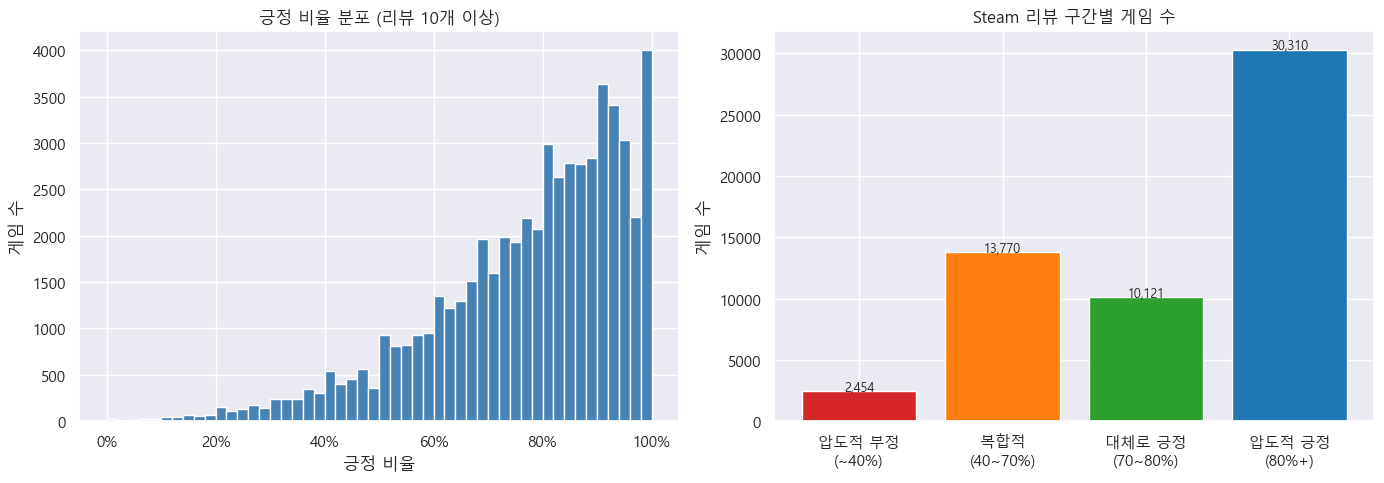

In [41]:
# ── 1-1. 긍정 비율 분포 ──────────────────────────────────────────
# 리뷰가 10개 이상인 게임만 의미 있는 샘플로 간주
reviewed = df[total_reviews >= 10].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(reviewed['Approval rate'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('긍정 비율 분포 (리뷰 10개 이상)')
axes[0].set_xlabel('긍정 비율')
axes[0].set_ylabel('게임 수')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Steam 공식 구간으로 카테고리화
bins   = [0, 0.4, 0.7, 0.8, 1.01]
labels = ['압도적 부정\n(~40%)', '복합적\n(40~70%)', '대체로 긍정\n(70~80%)', '압도적 긍정\n(80%+)']
reviewed['Review category'] = pd.cut(reviewed['Approval rate'], bins=bins, labels=labels, right=False)
cat_counts = reviewed['Review category'].value_counts().reindex(labels)

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
axes[1].bar(labels, cat_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Steam 리뷰 구간별 게임 수')
axes[1].set_ylabel('게임 수')
for i, v in enumerate(cat_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

메타크리틱 점수 보유 게임: 4,144개


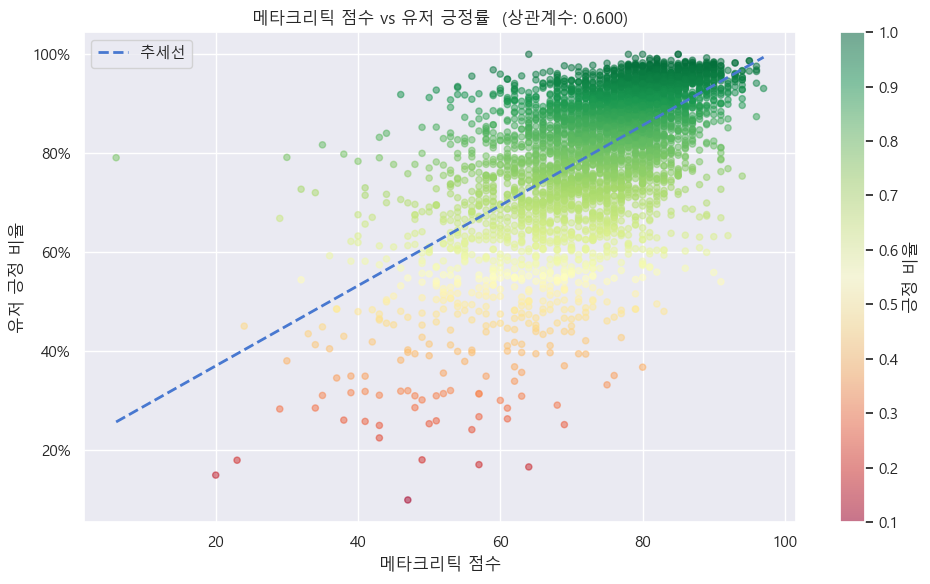

In [42]:
# ── 1-2. 메타크리틱 점수 vs 유저 긍정률 ─────────────────────────
meta = df[(df['Metacritic score'] > 0) & (df['Approval rate'].notna()) & (total_reviews >= 10)].copy()
print(f'메타크리틱 점수 보유 게임: {len(meta):,}개')

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    meta['Metacritic score'],
    meta['Approval rate'],
    c=meta['Approval rate'],
    cmap='RdYlGn',
    alpha=0.5,
    s=20
)
plt.colorbar(scatter, ax=ax, label='긍정 비율')

# 추세선
z = np.polyfit(meta['Metacritic score'], meta['Approval rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(meta['Metacritic score'].min(), meta['Metacritic score'].max(), 100)
ax.plot(x_line, p(x_line), 'b--', linewidth=2, label='추세선')

corr = meta['Metacritic score'].corr(meta['Approval rate'])
ax.set_title(f'메타크리틱 점수 vs 유저 긍정률  (상관계수: {corr:.3f})')
ax.set_xlabel('메타크리틱 점수')
ax.set_ylabel('유저 긍정 비율')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. 가격 분석

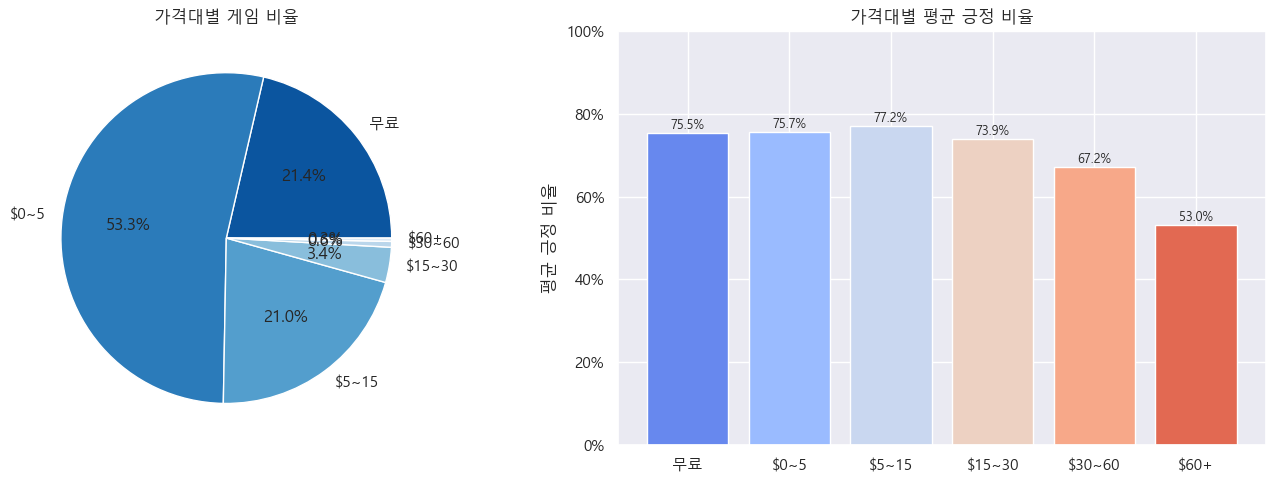

In [43]:
# ── 2-1. 무료 vs 유료 비율 & 가격대별 분포 ──────────────────────
df['Price tier'] = pd.cut(
    df['Price'],
    bins=[-0.01, 0, 5, 15, 30, 60, np.inf],
    labels=['무료', '$0~5', '$5~15', '$15~30', '$30~60', '$60+']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이차트 - 비율
tier_counts = df['Price tier'].value_counts().reindex(['무료','$0~5','$5~15','$15~30','$30~60','$60+'])
axes[0].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Blues_r', len(tier_counts)))
axes[0].set_title('가격대별 게임 비율')

# 가격대별 평균 긍정 비율
tier_approval = df.groupby('Price tier', observed=True)['Approval rate'].mean()
tier_approval = tier_approval.reindex(['무료','$0~5','$5~15','$15~30','$30~60','$60+'])
bars = axes[1].bar(tier_approval.index, tier_approval.values,
                   color=sns.color_palette('coolwarm', len(tier_approval)))
axes[1].set_title('가격대별 평균 긍정 비율')
axes[1].set_ylabel('평균 긍정 비율')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_ylim(0, 1)
for bar, v in zip(bars, tier_approval.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

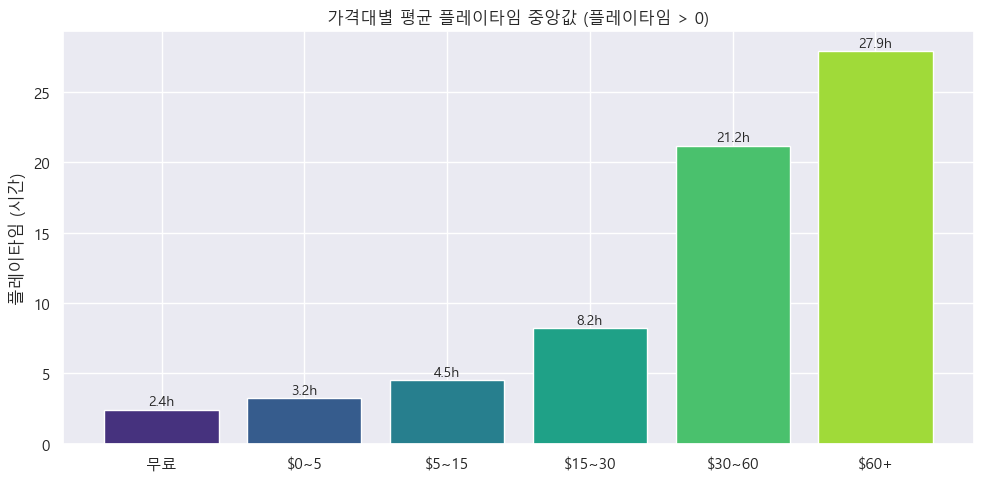

In [44]:
# ── 2-2. 가격대별 평균 플레이타임 ───────────────────────────────
# 플레이타임 0 제외 (실제 플레이한 게임만)
play = df[df['Average playtime forever'] > 0].copy()

tier_playtime = play.groupby('Price tier', observed=True)['Average playtime forever'].median()
tier_playtime = tier_playtime.reindex(['무료','$0~5','$5~15','$15~30','$30~60','$60+'])
tier_playtime_h = tier_playtime / 60  # 분 → 시간

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(tier_playtime_h.index, tier_playtime_h.values,
              color=sns.color_palette('viridis', len(tier_playtime_h)))
ax.set_title('가격대별 평균 플레이타임 중앙값 (플레이타임 > 0)')
ax.set_ylabel('플레이타임 (시간)')
for bar, v in zip(bars, tier_playtime_h.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}h', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 3. 장르 분석

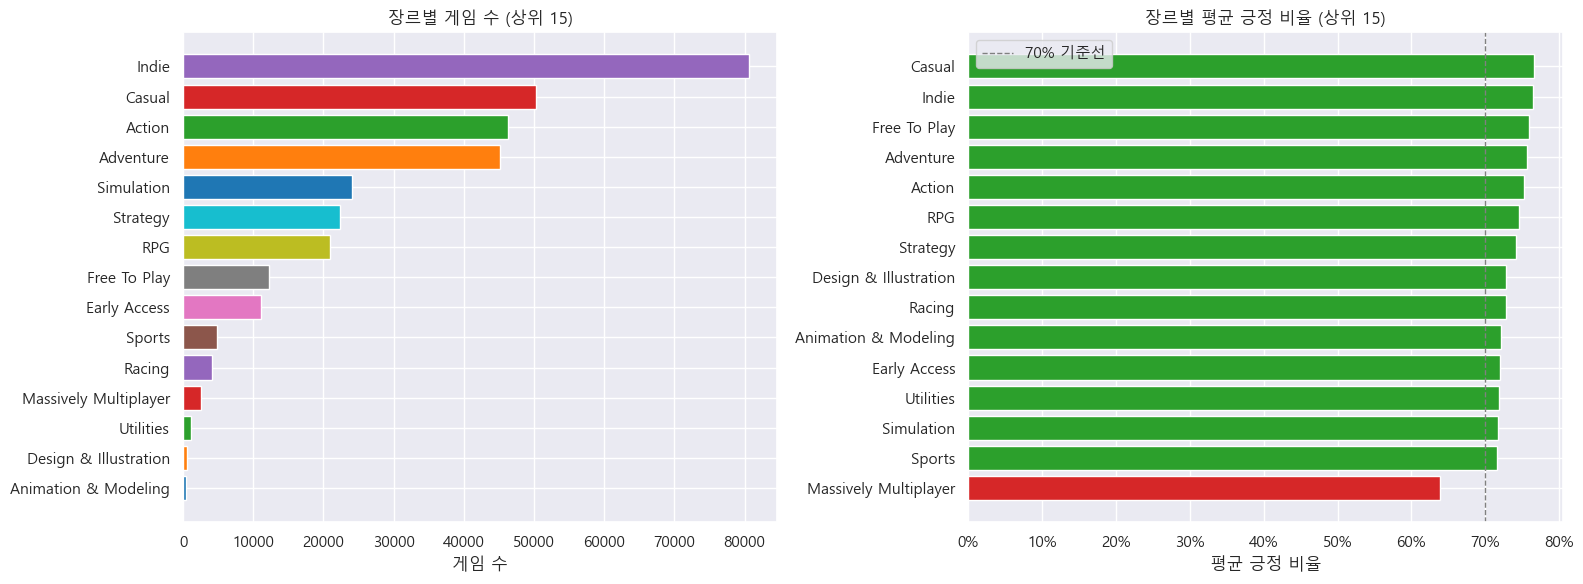

In [45]:
# ── 3-1. 상위 장르별 게임 수 & 평균 긍정 비율 ───────────────────
genres_exploded = df.dropna(subset=['Genres']).copy()
genres_exploded['Genres'] = genres_exploded['Genres'].str.split(',')
genres_exploded = genres_exploded.explode('Genres')
genres_exploded['Genres'] = genres_exploded['Genres'].str.strip()

top_genres = genres_exploded['Genres'].value_counts().head(15).index
genre_df = genres_exploded[genres_exploded['Genres'].isin(top_genres)]

genre_stats = genre_df.groupby('Genres').agg(
    게임수=('AppID', 'count'),
    평균긍정률=('Approval rate', 'mean'),
    평균가격=('Price', 'mean'),
).reindex(top_genres)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 게임 수
axes[0].barh(genre_stats.index[::-1], genre_stats['게임수'][::-1],
             color=sns.color_palette('tab10', 15))
axes[0].set_title('장르별 게임 수 (상위 15)')
axes[0].set_xlabel('게임 수')

# 평균 긍정 비율
sorted_genre = genre_stats.sort_values('평균긍정률', ascending=True)
colors = ['#d62728' if v < 0.7 else '#2ca02c' for v in sorted_genre['평균긍정률']]
axes[1].barh(sorted_genre.index, sorted_genre['평균긍정률'], color=colors)
axes[1].set_title('장르별 평균 긍정 비율 (상위 15)')
axes[1].set_xlabel('평균 긍정 비율')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].axvline(0.7, color='gray', linestyle='--', linewidth=1, label='70% 기준선')
axes[1].legend()

plt.tight_layout()
plt.show()

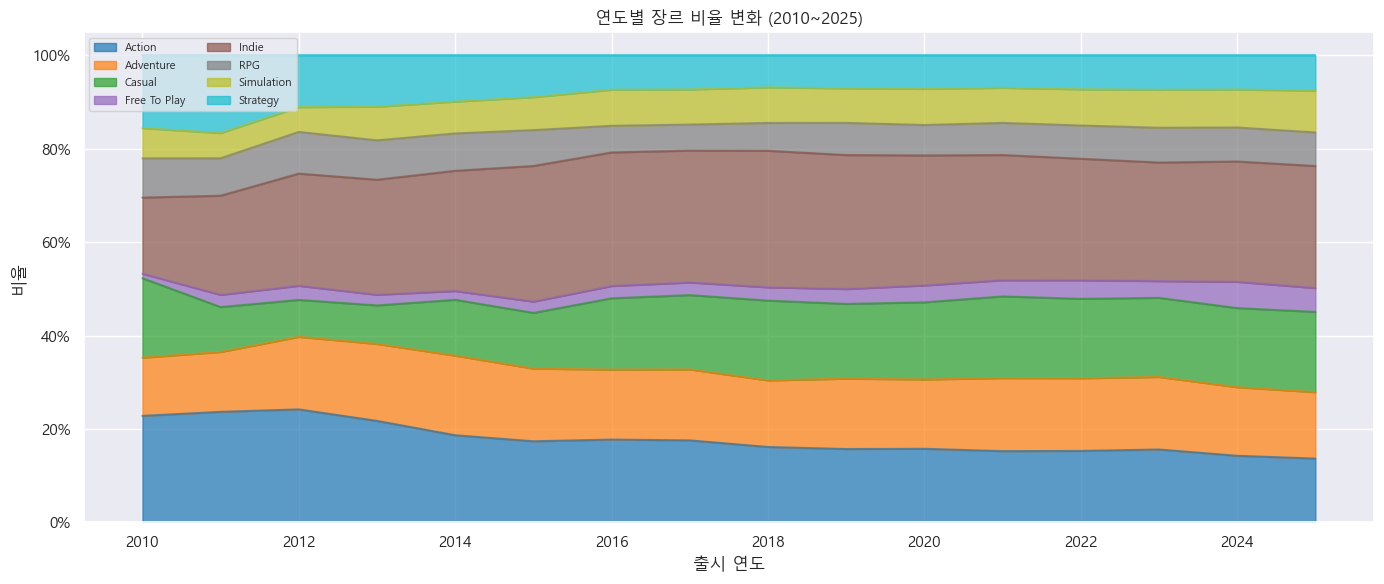

In [46]:
# ── 3-2. 연도별 인기 장르 변화 ──────────────────────────────────
genre_year = genres_exploded.dropna(subset=['Release year']).copy()
genre_year = genre_year[genre_year['Release year'].between(2010, 2025)]
genre_year = genre_year[genre_year['Genres'].isin(top_genres[:8])]  # 상위 8개만

pivot = genre_year.groupby(['Release year', 'Genres']).size().unstack(fill_value=0)
# 비율로 변환
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pct.plot(kind='area', ax=ax, alpha=0.7, colormap='tab10')
ax.set_title('연도별 장르 비율 변화 (2010~2025)')
ax.set_xlabel('출시 연도')
ax.set_ylabel('비율')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. 태그 분석

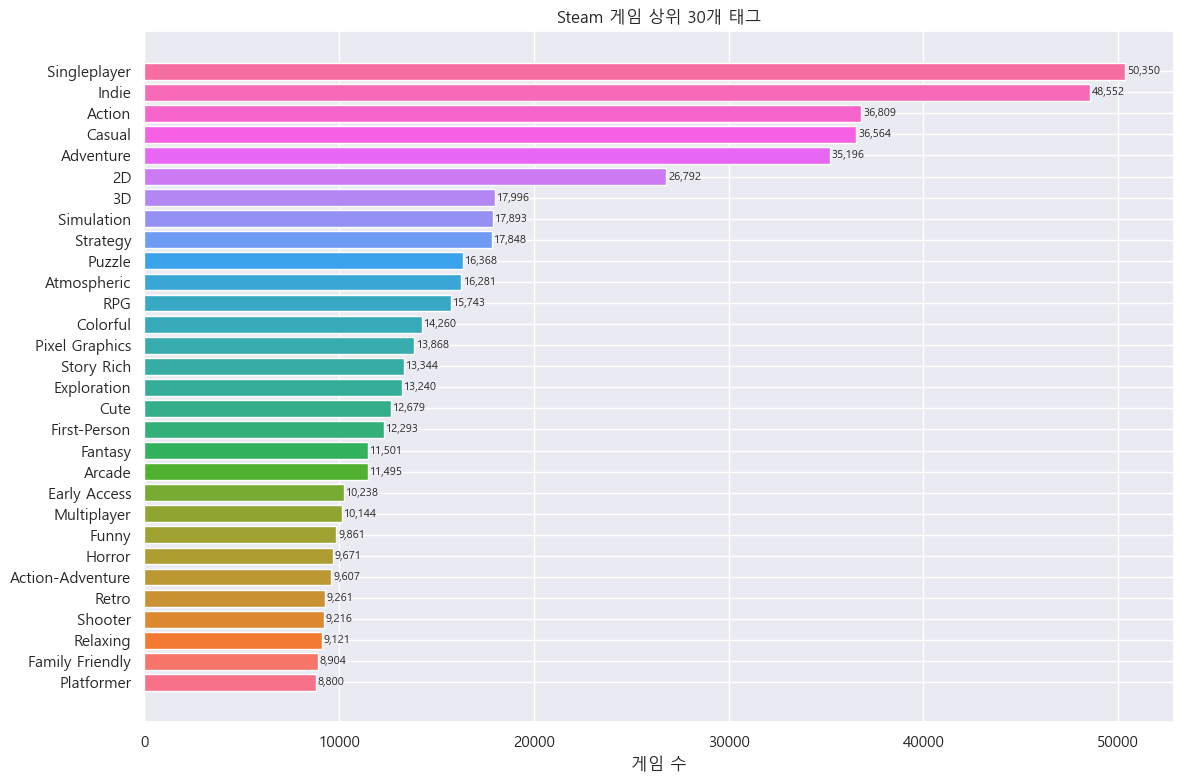

In [47]:
# ── 4-1. 상위 태그 빈도 ─────────────────────────────────────────
all_tags = df['Tags'].dropna().str.split(',').explode().str.strip()
top_tags = all_tags.value_counts().head(30)

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('husl', 30)
ax.barh(top_tags.index[::-1], top_tags.values[::-1], color=colors)
ax.set_title('Steam 게임 상위 30개 태그')
ax.set_xlabel('게임 수')
for i, v in enumerate(top_tags.values[::-1]):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

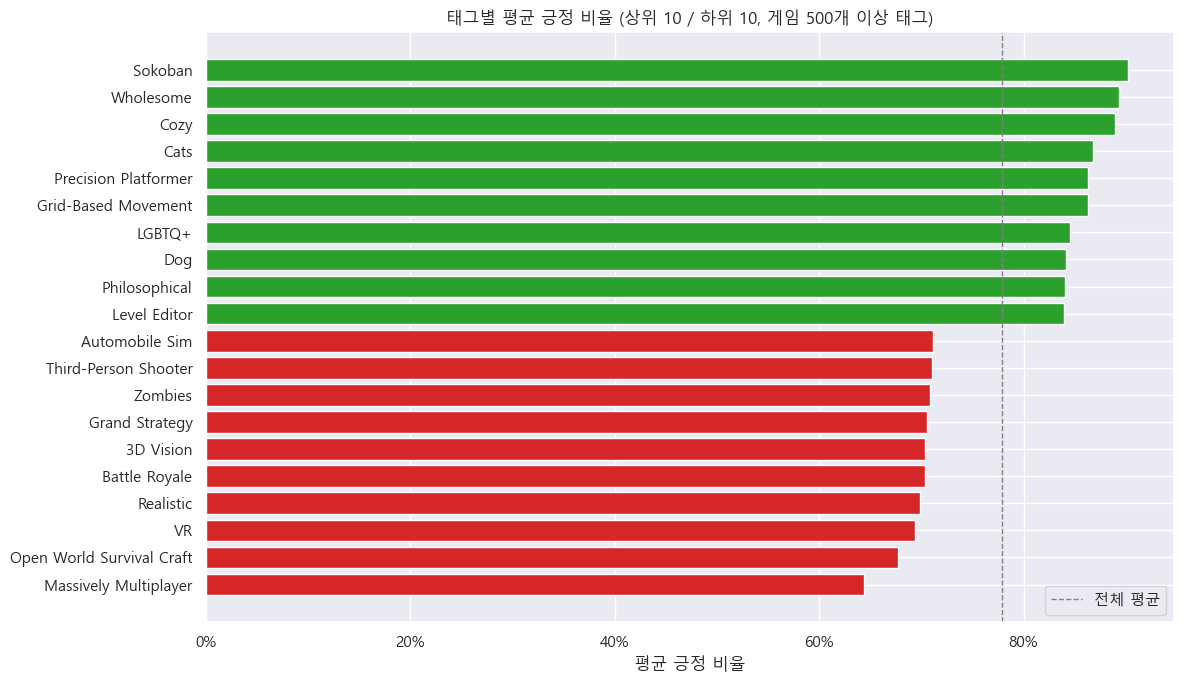

In [48]:
# ── 4-2. 태그별 평균 긍정 비율 (태그 500개 이상 게임만) ─────────
tags_df = df[['Tags', 'Approval rate']].dropna().copy()
tags_df['Tags'] = tags_df['Tags'].str.split(',')
tags_exploded = tags_df.explode('Tags')
tags_exploded['Tags'] = tags_exploded['Tags'].str.strip()

tag_approval = tags_exploded.groupby('Tags').agg(
    count=('Approval rate', 'count'),
    mean_approval=('Approval rate', 'mean')
).query('count >= 500').sort_values('mean_approval', ascending=False)

top20_tags = pd.concat([tag_approval.head(10), tag_approval.tail(10)])

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ca02c' if i < 10 else '#d62728' for i in range(len(top20_tags))]
ax.barh(top20_tags.index[::-1], top20_tags['mean_approval'][::-1], color=colors[::-1])
ax.set_title('태그별 평균 긍정 비율 (상위 10 / 하위 10, 게임 500개 이상 태그)')
ax.set_xlabel('평균 긍정 비율')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(tag_approval['mean_approval'].mean(), color='gray',
           linestyle='--', linewidth=1, label='전체 평균')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. 플레이타임 분석

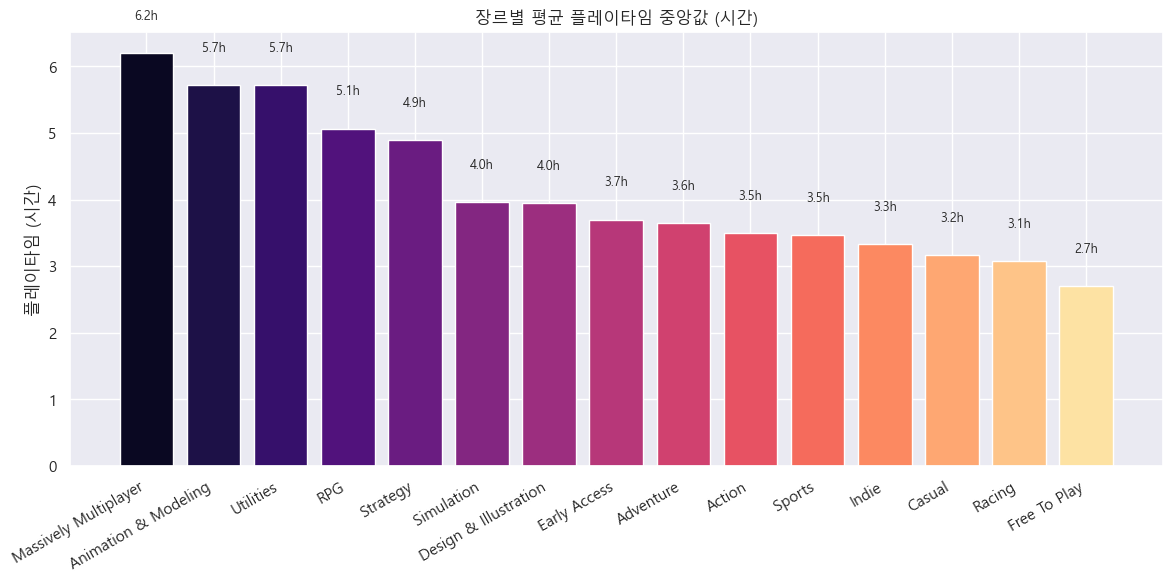

In [49]:
# ── 5-1. 장르별 평균 플레이타임 ─────────────────────────────────
play_genre = genres_exploded[genres_exploded['Average playtime forever'] > 0]
play_genre = play_genre[play_genre['Genres'].isin(top_genres)]

playtime_by_genre = play_genre.groupby('Genres')['Average playtime forever'].median() / 60
playtime_by_genre = playtime_by_genre.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(playtime_by_genre.index, playtime_by_genre.values,
       color=sns.color_palette('magma', len(playtime_by_genre)))
ax.set_title('장르별 평균 플레이타임 중앙값 (시간)')
ax.set_ylabel('플레이타임 (시간)')
ax.set_xticklabels(playtime_by_genre.index, rotation=30, ha='right')
for i, v in enumerate(playtime_by_genre.values):
    ax.text(i, v + 0.5, f'{v:.1f}h', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [50]:
# ── 5-2. 최근 인기 게임 찾기 (2주 플레이 비율) ──────────────────
# 전체 플레이 중 최근 2주 비율이 높을수록 현재도 활발히 플레이 중
recent = df[
    (df['Average playtime forever'] > 60) &   # 전체 평균 1시간 이상
    (df['Average playtime two weeks'] > 0) &
    (total_reviews >= 100)
].copy()

recent['Recent ratio'] = recent['Average playtime two weeks'] / recent['Average playtime forever']
top_recent = recent.nlargest(15, 'Recent ratio')[['Name', 'Release date', 'Genres',
                                                   'Average playtime forever',
                                                   'Average playtime two weeks',
                                                   'Recent ratio', 'Approval rate']]
top_recent['Average playtime forever'] = (top_recent['Average playtime forever'] / 60).round(1)
top_recent['Average playtime two weeks'] = (top_recent['Average playtime two weeks'] / 60).round(1)
top_recent['Recent ratio'] = top_recent['Recent ratio'].map('{:.1%}'.format)
top_recent['Approval rate'] = top_recent['Approval rate'].map('{:.1%}'.format)
top_recent.columns = ['이름', '출시일', '장르', '전체 평균(h)', '2주 평균(h)', '최근 비율', '긍정률']

print('=== 최근 가장 활발히 플레이되는 게임 Top 15 ===')
top_recent

=== 최근 가장 활발히 플레이되는 게임 Top 15 ===


,이름,출시일,장르,전체 평균(h),2주 평균(h),최근 비율,긍정률
69001,LARA CROFT AND THE TEMPLE OF OSIRIS™,2014-12-08,"Action,Adventure",6.9,100.8,1457.6%,67.9%
114568,NEKOPARA Vol. 1,2014-12-29,"Casual,Indie",26.3,333.6,1269.1%,95.2%
49767,Bulb Boy,2015-10-29,"Adventure,Indie",3.3,26.4,799.0%,88.2%
30858,Atomfall,2025-03-27,"Action,Adventure",9.3,60.1,643.8%,78.8%
89898,Deus Ex: Invisible War,2007-03-29,Action,1.7,10.1,596.1%,57.7%
5019,LEGO® Batman™ 2: DC Super Heroes,2012-06-22,"Action,Adventure",11.4,67.0,585.7%,94.2%
104019,Worm.is: The Game,2016-05-04,"Casual,Free To Play",17.6,101.0,572.0%,80.8%
76560,Wolfenstein: Youngblood,2019-07-25,Action,12.7,71.5,564.2%,44.0%
2301,Plan B: Terraform,2025-08-29,"Indie,Simulation,Strategy",13.6,73.1,538.2%,91.5%
114859,Rec Room,2021-09-02,"Adventure,Casual,Massively Multiplayer,Free To...",6.8,34.8,515.6%,89.5%


---
## 6. 플랫폼 & 개발사 분석

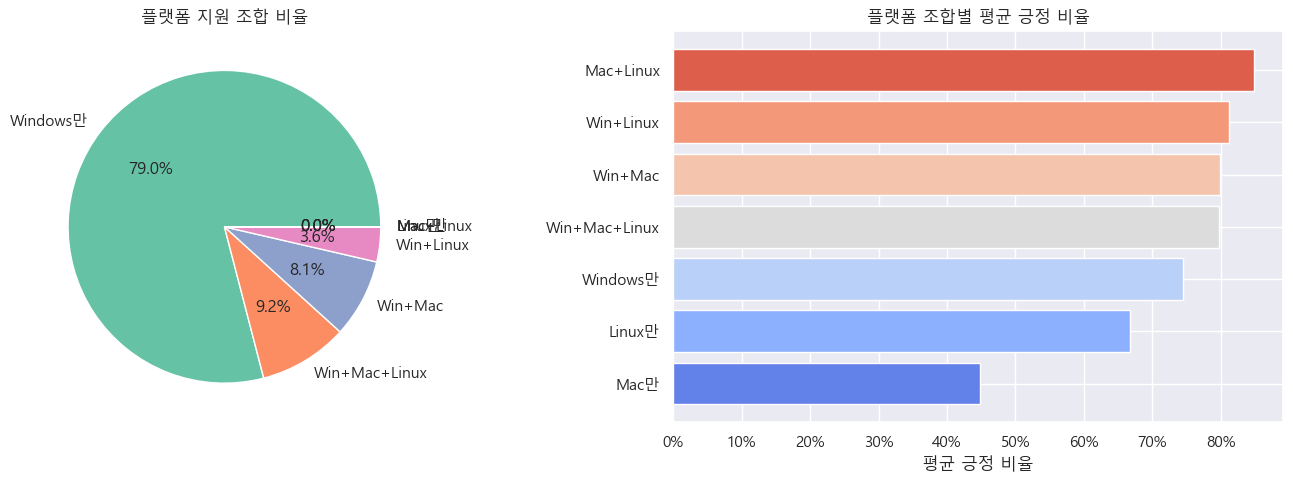

In [51]:
# ── 6-1. 플랫폼 지원 조합 분석 ──────────────────────────────────
df['Platform'] = (
    df['Windows'].map({True: 'W', False: ''}) +
    df['Mac'].map({True: 'M', False: ''}) +
    df['Linux'].map({True: 'L', False: ''})
)
platform_label = {
    'W': 'Windows만', 'WM': 'Win+Mac', 'WL': 'Win+Linux',
    'WML': 'Win+Mac+Linux', 'M': 'Mac만', 'L': 'Linux만',
    'ML': 'Mac+Linux', '': '없음'
}
df['Platform label'] = df['Platform'].map(platform_label)

platform_counts = df['Platform label'].value_counts()
platform_approval = df.groupby('Platform label')['Approval rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(platform_counts, labels=platform_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2', len(platform_counts)))
axes[0].set_title('플랫폼 지원 조합 비율')

sorted_pa = platform_approval.sort_values(ascending=True).dropna()
axes[1].barh(sorted_pa.index, sorted_pa.values,
             color=sns.color_palette('coolwarm', len(sorted_pa)))
axes[1].set_title('플랫폼 조합별 평균 긍정 비율')
axes[1].set_xlabel('평균 긍정 비율')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

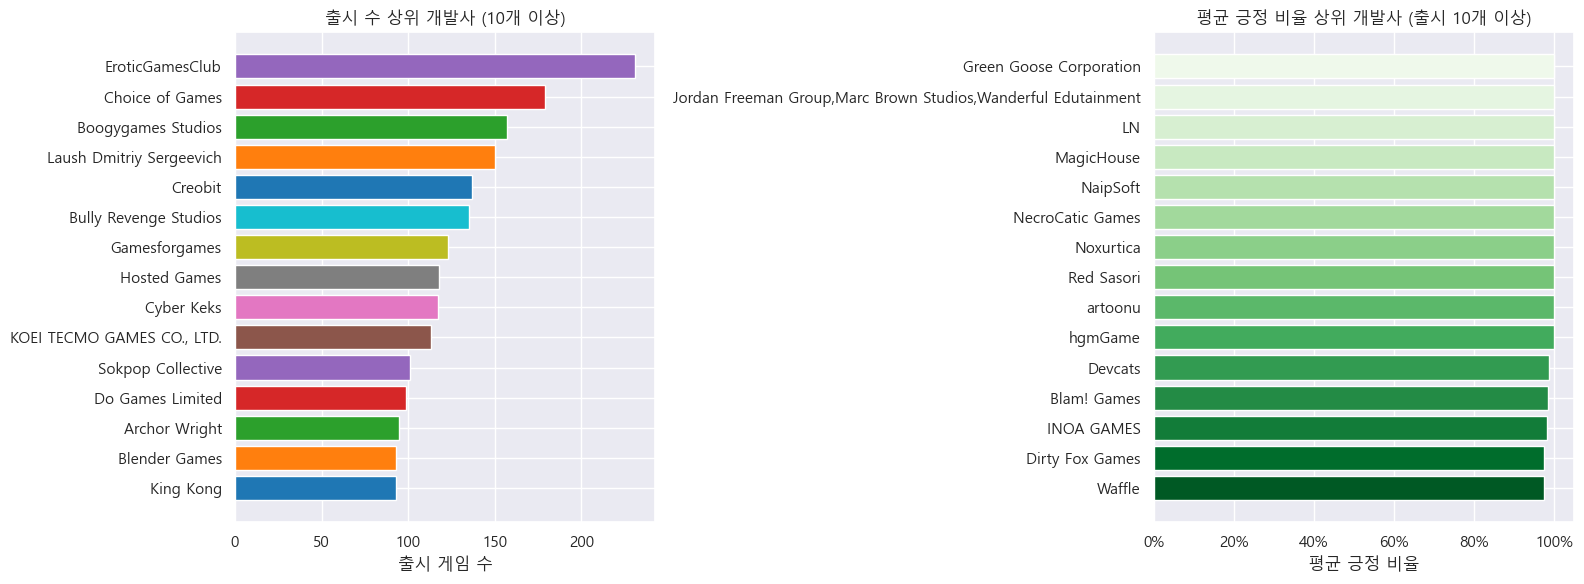

In [52]:
# ── 6-2. 개발사 분석 (출시 10개 이상 개발사) ────────────────────
dev_stats = df.groupby('Developers').agg(
    출시수=('AppID', 'count'),
    평균긍정률=('Approval rate', 'mean'),
    평균가격=('Price', 'mean'),
    평균플레이타임=('Average playtime forever', 'mean')
).query('출시수 >= 10')

dev_stats['평균플레이타임'] = dev_stats['평균플레이타임'] / 60

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 출시 수 Top 15
top_dev_count = dev_stats.nlargest(15, '출시수')
axes[0].barh(top_dev_count.index[::-1], top_dev_count['출시수'][::-1],
             color=sns.color_palette('tab10', 15))
axes[0].set_title('출시 수 상위 개발사 (10개 이상)')
axes[0].set_xlabel('출시 게임 수')

# 평균 긍정률 Top 15
top_dev_approval = dev_stats.nlargest(15, '평균긍정률')
axes[1].barh(top_dev_approval.index[::-1], top_dev_approval['평균긍정률'][::-1],
             color=sns.color_palette('Greens_r', 15))
axes[1].set_title('평균 긍정 비율 상위 개발사 (출시 10개 이상)')
axes[1].set_xlabel('평균 긍정 비율')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

---
## 7. 시계열 분석

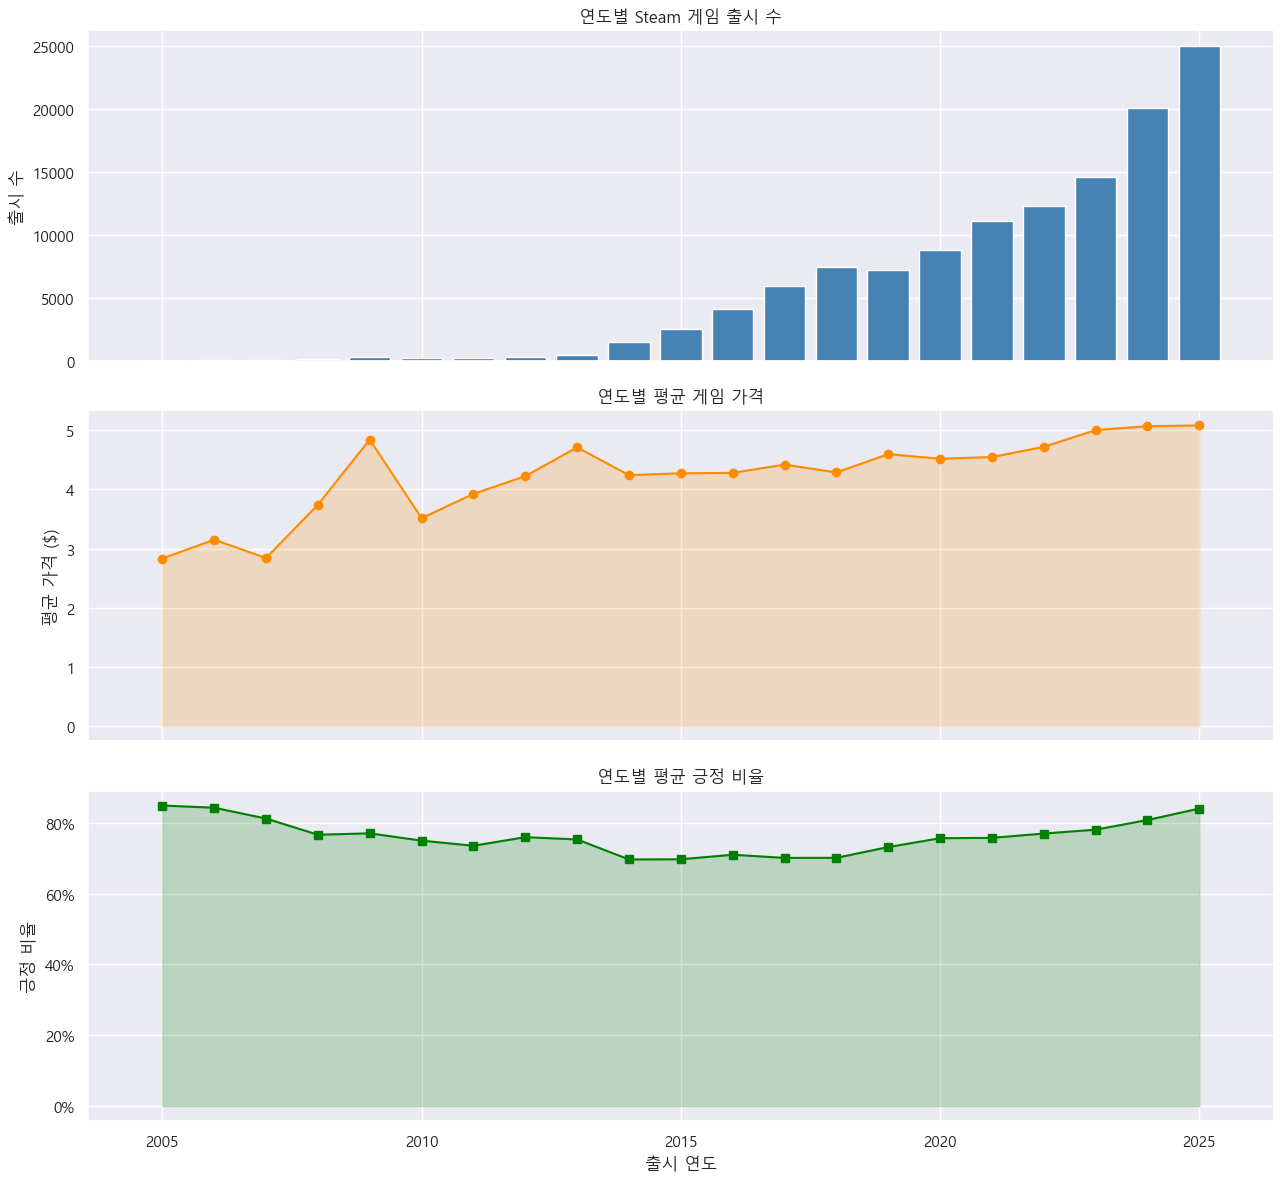

In [53]:
# ── 7-1. 연도별 출시 수 & 평균 가격 변화 ────────────────────────
yearly = df[df['Release year'].between(2005, 2025)].groupby('Release year').agg(
    출시수=('AppID', 'count'),
    평균가격=('Price', 'mean'),
    평균긍정률=('Approval rate', 'mean')
)

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

axes[0].bar(yearly.index, yearly['출시수'], color='steelblue')
axes[0].set_title('연도별 Steam 게임 출시 수')
axes[0].set_ylabel('출시 수')

axes[1].plot(yearly.index, yearly['평균가격'], marker='o', color='darkorange')
axes[1].fill_between(yearly.index, yearly['평균가격'], alpha=0.2, color='darkorange')
axes[1].set_title('연도별 평균 게임 가격')
axes[1].set_ylabel('평균 가격 ($)')

axes[2].plot(yearly.index, yearly['평균긍정률'], marker='s', color='green')
axes[2].fill_between(yearly.index, yearly['평균긍정률'], alpha=0.2, color='green')
axes[2].set_title('연도별 평균 긍정 비율')
axes[2].set_ylabel('긍정 비율')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[2].set_xlabel('출시 연도')

plt.tight_layout()
plt.show()

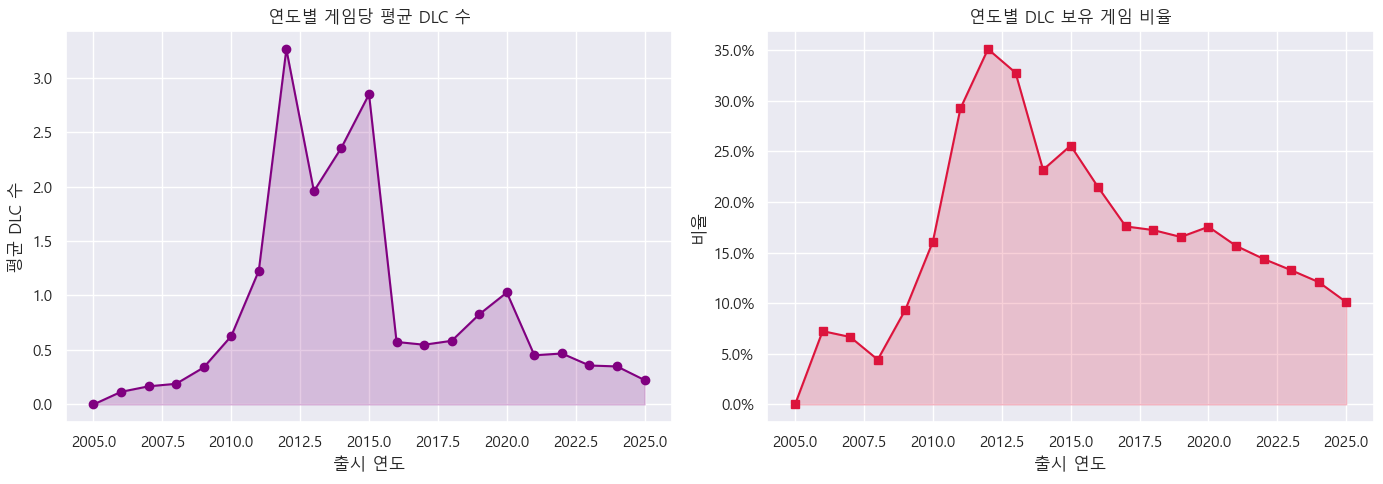

In [54]:
# ── 7-2. 연도별 DLC Count 트렌드 ────────────────────────────────
dlc_trend = df[df['Release year'].between(2005, 2025)].groupby('Release year').agg(
    평균DLC=('DLC Count', 'mean'),
    DLC보유비율=('DLC Count', lambda x: (x > 0).mean())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dlc_trend.index, dlc_trend['평균DLC'], marker='o', color='purple')
axes[0].fill_between(dlc_trend.index, dlc_trend['평균DLC'], alpha=0.2, color='purple')
axes[0].set_title('연도별 게임당 평균 DLC 수')
axes[0].set_ylabel('평균 DLC 수')
axes[0].set_xlabel('출시 연도')

axes[1].plot(dlc_trend.index, dlc_trend['DLC보유비율'], marker='s', color='crimson')
axes[1].fill_between(dlc_trend.index, dlc_trend['DLC보유비율'], alpha=0.2, color='crimson')
axes[1].set_title('연도별 DLC 보유 게임 비율')
axes[1].set_ylabel('비율')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlabel('출시 연도')

plt.tight_layout()
plt.show()

---
## 8. 종합 인사이트: 성공 게임 요인 분석

성공 게임: 6,858개  |  비교 게임: 15,942개



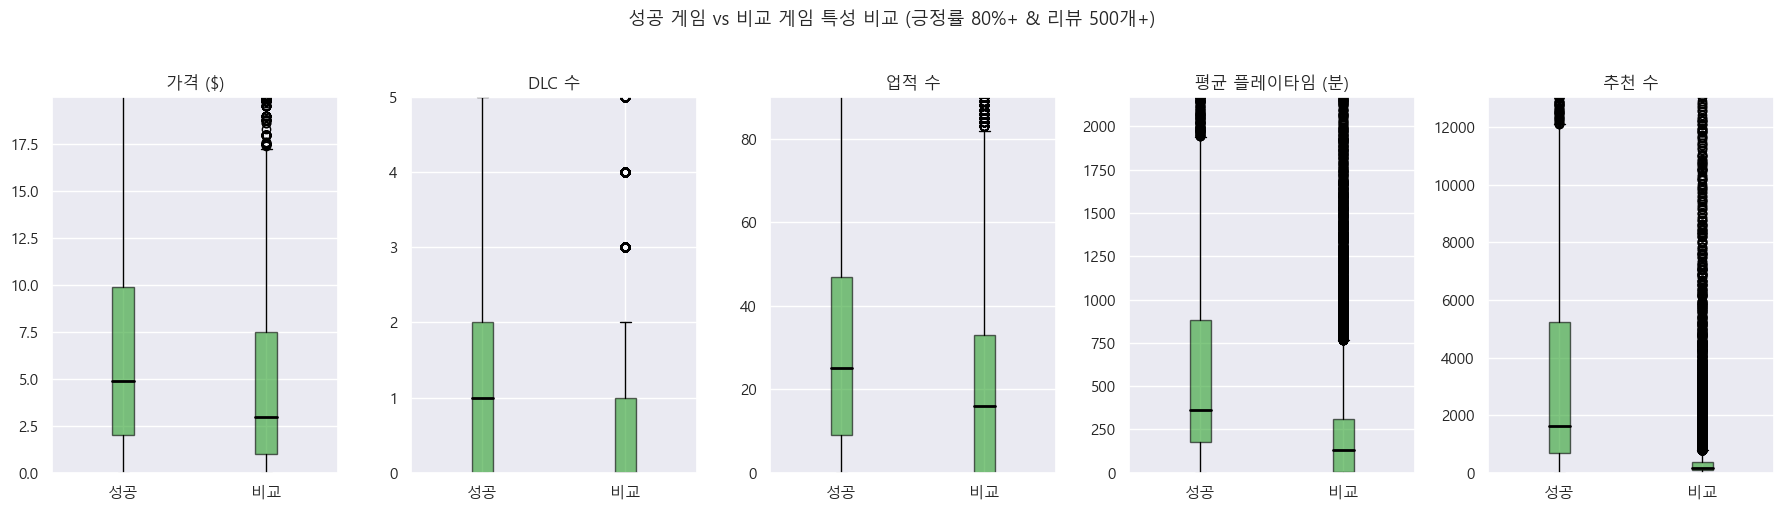

In [55]:
# ── 8. 성공 게임 정의 & 비성공 게임과 비교 ──────────────────────
# 성공 기준: 긍정 비율 80% 이상 + 리뷰 500개 이상
qualified = df[total_reviews >= 100].copy()
qualified['Is success'] = (qualified['Approval rate'] >= 0.8) & (total_reviews[qualified.index] >= 500)

success = qualified[qualified['Is success']]
others  = qualified[~qualified['Is success']]

print(f'성공 게임: {len(success):,}개  |  비교 게임: {len(others):,}개')
print()

compare_cols = {
    'Price': '가격 ($)',
    'DLC Count': 'DLC 수',
    'Achievements': '업적 수',
    'Average playtime forever': '평균 플레이타임 (분)',
    'Recommendations': '추천 수',
}

fig, axes = plt.subplots(1, len(compare_cols), figsize=(18, 5))

for ax, (col, label) in zip(axes, compare_cols.items()):
    data_s = success[col].dropna()
    data_o = others[col].dropna()
    ax.boxplot([data_s, data_o], labels=['성공', '비교'],
               patch_artist=True,
               boxprops=dict(facecolor='#2ca02c', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(label)
    # 이상치 제거를 위해 95% 분위수로 y축 제한
    upper = qualified[col].quantile(0.95)
    ax.set_ylim(0, upper)

fig.suptitle('성공 게임 vs 비교 게임 특성 비교 (긍정률 80%+ & 리뷰 500개+)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()